In [1]:
# ==========================================
# Liver Disease Prediction using ILPD Dataset
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../datasets/liver/Indian Liver Patient Dataset (ILPD).csv")

print("Dataset Loaded Successfully")

print("\nDataset Shape:", df.shape)

df.head()

Dataset Loaded Successfully

Dataset Shape: (583, 11)


,age,gender,tot_bilirubin,direct_bilirubin,tot_proteins,albumin,ag_ratio,sgpt,sgot,alkphos,is_patient
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print("Dataset Information")
print("=" * 50)

df.info()

print("\n")

print("Missing Values")
print("=" * 50)

print(df.isnull().sum())

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    int64  
 1   gender            583 non-null    str    
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    int64  
 5   albumin           583 non-null    int64  
 6   ag_ratio          583 non-null    int64  
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           579 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(5), int64(5), str(1)
memory usage: 52.8 KB


Missing Values
age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
a

In [4]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,583.0,NaN,NaN,NaN,44.746141,16.189833,4.0,33.0,45.0,58.0,90.0
gender,583,2,Male,441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tot_bilirubin,583.0,NaN,NaN,NaN,3.298799,6.209522,0.4,0.8,1.0,2.6,75.0
direct_bilirubin,583.0,NaN,NaN,NaN,1.486106,2.808498,0.1,0.2,0.3,1.3,19.7
tot_proteins,583.0,NaN,NaN,NaN,290.576329,242.937989,63.0,175.5,208.0,298.0,2110.0
albumin,583.0,NaN,NaN,NaN,80.713551,182.620356,10.0,23.0,35.0,60.5,2000.0
ag_ratio,583.0,NaN,NaN,NaN,109.910806,288.918529,10.0,25.0,42.0,87.0,4929.0
sgpt,583.0,NaN,NaN,NaN,6.48319,1.085451,2.7,5.8,6.6,7.2,9.6
sgot,583.0,NaN,NaN,NaN,3.141852,0.795519,0.9,2.6,3.1,3.8,5.5
alkphos,579.0,NaN,NaN,NaN,0.947064,0.319592,0.3,0.7,0.93,1.1,2.8


is_patient
1    416
2    167
Name: count, dtype: int64


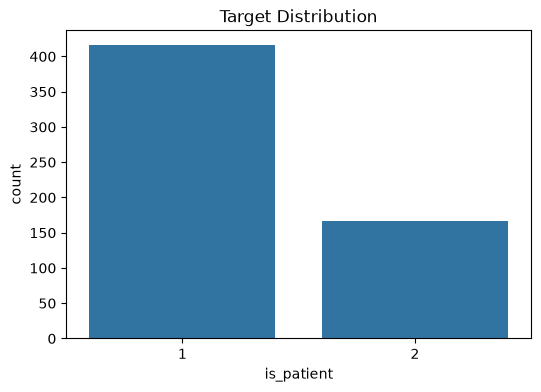

In [5]:
# ==========================================
# Target Distribution
# ==========================================

print(df["is_patient"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="is_patient",
    data=df
)

plt.title("Target Distribution")

plt.show()

In [6]:
# ==========================================
# Data Cleaning
# ==========================================

# Remove extra spaces
df["gender"] = df["gender"].astype(str).str.strip()

# Convert Gender to numeric
df["gender"] = df["gender"].map({
    "Male": 1,
    "Female": 0
})

# Convert target
# 1 = Liver Disease
# 2 = Healthy

df["is_patient"] = df["is_patient"].replace({
    1: 1,
    2: 0
})

print(df.head())

   age  gender  tot_bilirubin  direct_bilirubin  tot_proteins  albumin  \
0   65       0            0.7               0.1           187       16   
1   62       1           10.9               5.5           699       64   
2   62       1            7.3               4.1           490       60   
3   58       1            1.0               0.4           182       14   
4   72       1            3.9               2.0           195       27   

   ag_ratio  sgpt  sgot  alkphos  is_patient  
0        18   6.8   3.3     0.90           1  
1       100   7.5   3.2     0.74           1  
2        68   7.0   3.3     0.89           1  
3        20   6.8   3.4     1.00           1  
4        59   7.3   2.4     0.40           1  


In [7]:
# ==========================================
# Missing Value Handling
# ==========================================

from sklearn.impute import SimpleImputer

features = [
    "age",
    "gender",
    "tot_bilirubin",
    "direct_bilirubin",
    "tot_proteins",
    "albumin",
    "ag_ratio",
    "sgpt",
    "sgot",
    "alkphos"
]

imputer = SimpleImputer(strategy="median")

df[features] = imputer.fit_transform(df[features])

print(df.isnull().sum())

age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             0
is_patient          0
dtype: int64


In [8]:
# ==========================================
# Verify Dataset
# ==========================================

print(df.info())

print()

print(df.head())

print()

print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               583 non-null    float64
 1   gender            583 non-null    float64
 2   tot_bilirubin     583 non-null    float64
 3   direct_bilirubin  583 non-null    float64
 4   tot_proteins      583 non-null    float64
 5   albumin           583 non-null    float64
 6   ag_ratio          583 non-null    float64
 7   sgpt              583 non-null    float64
 8   sgot              583 non-null    float64
 9   alkphos           583 non-null    float64
 10  is_patient        583 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 50.2 KB
None

    age  gender  tot_bilirubin  direct_bilirubin  tot_proteins  albumin  \
0  65.0     0.0            0.7               0.1         187.0     16.0   
1  62.0     1.0           10.9               5.5         699.0     64.0   
2  62.0     

In [9]:
# ==========================================
# Features & Target
# ==========================================

X = df.drop("is_patient", axis=1)

y = df["is_patient"]

print("X Shape :", X.shape)

print("y Shape :", y.shape)

X Shape : (583, 10)
y Shape : (583,)


In [10]:
# ==========================================
# Final NaN Check
# ==========================================

print(X.isnull().sum())

print()

print("Total NaN :", X.isnull().sum().sum())

age                 0
gender              0
tot_bilirubin       0
direct_bilirubin    0
tot_proteins        0
albumin             0
ag_ratio            0
sgpt                0
sgot                0
alkphos             0
dtype: int64

Total NaN : 0


In [11]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (466, 10)
Testing Data : (117, 10)


In [12]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [13]:
# ==========================================
# Verify No NaN After Scaling
# ==========================================

import numpy as np

print("NaN in X_train_scaled :", np.isnan(X_train_scaled).sum())

print("NaN in X_test_scaled :", np.isnan(X_test_scaled).sum())

NaN in X_train_scaled : 0
NaN in X_test_scaled : 0


In [14]:
# ==========================================
# Machine Learning Models
# ==========================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Naive Bayes": GaussianNB()

}

print("Models Created Successfully")

Models Created Successfully


In [15]:
# ==========================================
# Train Models
# ==========================================

results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred)

    })

print("Training Completed Successfully")

Training Completed Successfully


In [16]:
# ==========================================
# Compare All Models
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.735043,0.795455,0.843373,0.818713
1,KNN,0.683761,0.739583,0.855422,0.793296
2,Logistic Regression,0.735043,0.919355,0.686747,0.786207
3,Decision Tree,0.623932,0.719101,0.771084,0.744186
4,SVM,0.692308,0.912281,0.626506,0.742857
5,Naive Bayes,0.641026,0.976744,0.506024,0.666667


In [17]:
# ==========================================
# Select Best Model
# ==========================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [18]:
# ==========================================
# Classification Report
# ==========================================

y_pred = best_model.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.55      0.47      0.51        34
           1       0.80      0.84      0.82        83

    accuracy                           0.74       117
   macro avg       0.67      0.66      0.66       117
weighted avg       0.72      0.74      0.73       117



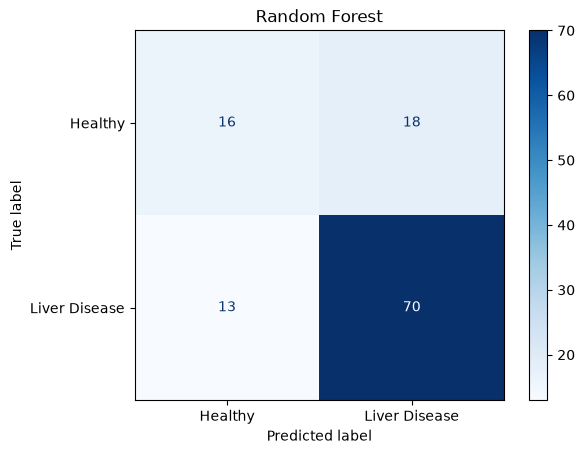

[[16 18]
 [13 70]]


In [19]:
# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "Liver Disease"]
).plot(cmap="Blues")

plt.title(best_model_name)

plt.show()

print(cm)

In [20]:
# ==========================================
# ROC-AUC Score
# ==========================================

y_prob = best_model.predict_proba(
    X_test_scaled
)[:, 1]

roc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score :", round(roc, 4))

ROC-AUC Score : 0.7736


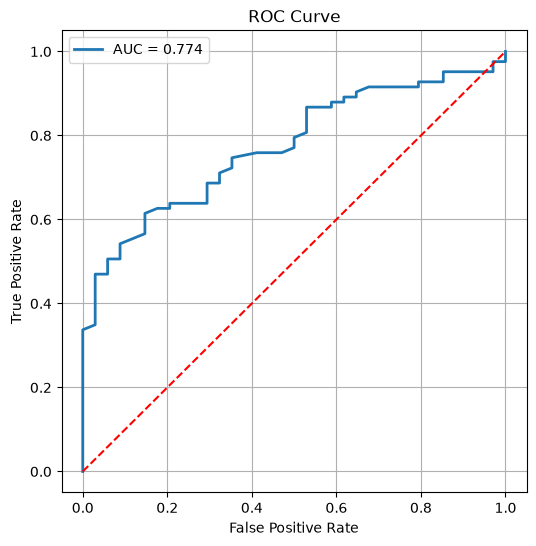

In [21]:
# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc:.3f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="red"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [22]:
# ==========================================
# Save Model
# ==========================================

feature_columns = X.columns.tolist()

MODEL_DIR = Path("../trained_models")

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(
    best_model,
    MODEL_DIR / "liver_model.pkl"
)

joblib.dump(
    scaler,
    MODEL_DIR / "liver_scaler.pkl"
)

joblib.dump(
    feature_columns,
    MODEL_DIR / "liver_columns.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
